# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
importlib.reload(up)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


<module 'src.util_process_prolific' from '/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_process_prolific.py'>





### Import human data

In [2]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_azim_spotlight_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("azimuth_spotlight_experiment_update/data/*.json"))

len(human_fnames)

524

In [ ]:
part_str = "6679a7429f703992d1619bdc"
any([part_str in f.stem for f in human_fnames])

True

## Process Human Results

In [4]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
results_df = results_df[results_df.itd_passed == True]
results_df = results_df[results_df.hearing_loss == False]
results_df = results_df[results_df.id_version >= 0]
# results_df = results_df[results_df.over_ear_hf == True]


## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_azim_spotlight_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": (v['target_azim'], v['dist_azim_delta'], v['distractor_azim']) for k,v in stim_cond_map.items()}

# add as columns 
results_df['condition'], results_df['target_azim'], results_df['dist_azim_delta'], results_df['distractor_azim'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_target_azim_and_dist_detla(x, stim_cond_map=stim_cond_map)))

# Add SRM trials as condition 
results_df.loc[results_df.srm_trial == 1, 'condition'] = 'srm_trial'


# # remap azimuths to be in the range -180 to 180 for plotting 
remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 
remap_azim = np.vectorize(remap_azim)
results_df['target_azim'] = remap_azim(results_df['target_azim'])
results_df['distractor_azim'] = remap_azim(results_df['distractor_azim'])
results_df['dist_azim_delta'] = remap_azim(results_df['dist_azim_delta'])


# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()

# trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 144 # 112 trials + 32 srm trials
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() >= total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')

Unterminated string starting at: line 1 column 59847 (char 59846)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment_update/data/subj_589fa5e2a7d4580001042e86.json
Unterminated string starting at: line 1 column 239378 (char 239377)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment_update/data/subj_669c14c5463407058421c908.json
Unterminated string starting at: line 1 column 12043 (char 12042)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment_update/data/subj_5d990c47f90743021e01d361.json
Unterminated string starting at: line 1 column 179435 (char 179434)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment_update/data/subj_65fcdef120c3e7513256ac68.json
Unterminated string starting at: line 1 column 71775 (char 71774)
/mindhive/mcdermott/www/imgriff/msjspsych/azimuth_spotlight_experiment_update/data/subj_630cc9747cb664e8a03c29f0.json


In [5]:
results_df[results_df.id_subject == '6679a7429f703992d1619bdc']

,success,timeout,failed_images,failed_audio,failed_video,trial_type,trial_index,time_elapsed,internal_node_id,output_filename,...,srm_trial,correct_response,trial_num,correct,n_correct,n_incorrect,condition,target_azim,dist_azim_delta,distractor_azim


In [6]:
trial_results.condition.unique()

array(['spatialized', 'catch_trial', 'srm_trial'], dtype=object)

In [ ]:
# trial_results = trial_results[trial_results.target_azim != - 90]

In [8]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  66
N good participants  66



#### Add re-scored performance based on entries included in excerpt transcripts  

In [ ]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_azim_spotlight_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



In [10]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_azim_spotlight_stim_manifest.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'word',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')
analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
distractor_words = analysis_df.distractor_word.values
distractor_transcripts = analysis_df.distractor_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
                            if not (isinstance(distractor_transcript, float)) else np.nan
                            for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
                            ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

analysis_df = analysis_df[analysis_df.condition != 'catch_trial']


In [11]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [12]:
analysis_df.condition.unique()

array(['spatialized', 'srm_trial'], dtype=object)

In [ ]:
analysis_df.columns

Index(['trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'rt', 'response', 'stimulus', 'over_ear_hf',
       'hearing_loss', 'itd_passed', 'response_str', 'catch_trial',
       'srm_trial', 'correct_response', 'trial_num', 'correct', 'n_correct',
       'n_incorrect', 'condition', 'target_azim', 'dist_azim_delta',
       'distractor_azim', 'accuracy', 'stim_name', 'word',
       'target_transcripts', 'distractor_transcripts', 'distractor_word',
       'confusions', 'adjusted_accuracy', 'adjusted_confusions'],
      dtype='object')

In [14]:
analysis_df.adjusted_accuracy.mean()

0.6791877104377104

# Get median split based on SRM trials 

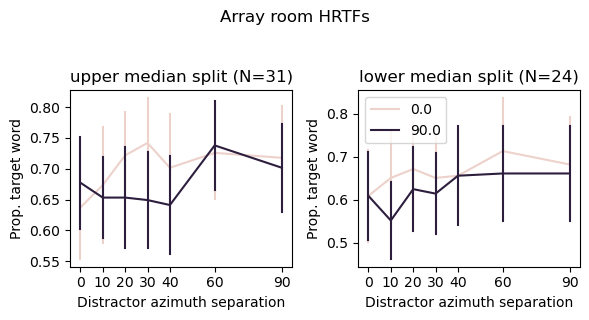

In [15]:
to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()

# srm_to_analyze = to_analyze_df[to_analyze_df.distractor_azim.isin([0, 90]) ]
srm_to_analyze =  to_analyze_df[to_analyze_df.condition == 'srm_trial']

srm_summary_df = (srm_to_analyze.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

# flatten multiindex 
srm_summary_df.columns = ['_'.join(col).strip() for col in srm_summary_df.columns.values]
# remove trailing underscore
srm_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in srm_summary_df.columns.values]

for_part_summary_df = to_analyze_df[to_analyze_df.condition != 'srm_trial']
# for_part_summary_df = to_analyze_df[to_analyze_df.distractor_azim < 90]

part_summary_df = (for_part_summary_df.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


# cutoff = 0.5

# participant_names = srm_summary_df.id_subject.unique()
# valid_participants = participant_names[srm_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= cutoff ]
# print(f"Number of participants with mean adjusted accuracy >= {cutoff} is {len(valid_participants)}")
# srm_summary_df = srm_summary_df[srm_summary_df.id_subject.isin(valid_participants)]

def get_avg_srm(part_df, target_azims = [0, 90]):
    # front srm 
    srms = []
    for target_azim in target_azims:
        front_data = part_df[part_df.target_azim == target_azim]
        co_loc = front_data[front_data.dist_azim_delta == 0].adjusted_accuracy_mean.mean()
        max_sep = front_data[front_data.dist_azim_delta == 90].adjusted_accuracy_mean.mean()
        srms.append(max_sep - co_loc)
    return np.mean(srms)


def get_srm(part_df):
    """Calculate SRM for a participant"""
    co_loc = part_df[part_df.dist_azim_delta == 0].adjusted_accuracy_mean.mean()
    max_sep = part_df[part_df.dist_azim_delta == 90].adjusted_accuracy_mean.mean()
    return max_sep - co_loc

srm = srm_summary_df.groupby('id_subject').apply(get_srm)
# srm = srm_summary_df.groupby('id_subject').apply(get_avg_srm)
median_srm = srm.quantile(0.5) #srm.median()
upper_split_parts = srm[srm > median_srm].index
lower_split_parts = srm[srm < median_srm].index

upper_split_df = part_summary_df[part_summary_df.id_subject.isin(upper_split_parts)]
lower_split_df = part_summary_df[part_summary_df.id_subject.isin(lower_split_parts)]

# plot split half data
n_pannels = 2
height, width = 3, 3*n_pannels
fig, axs = plt.subplots(1, n_pannels, figsize=(width, height), sharey=False)

plot_dict = {'upper': upper_split_df, 'lower': lower_split_df}
plot_keys = list(plot_dict.keys())  

for ix, cutoff in enumerate(range(n_pannels)):
    split  = plot_keys[ix]
    data = plot_dict[split]
    N = data.id_subject.nunique()
    g = sns.lineplot(data=data,
                    x='dist_azim_delta',
                    y='adjusted_accuracy_mean',
                    hue='target_azim',
                    errorbar=('se', 2),
                    err_style='bars',
                    ax=axs[ix]
                )
    g.set_xlabel("Distractor azimuth separation")
    g.set_ylabel( "Prop. target word")
    g.set(xticks=data.dist_azim_delta.unique())
    g.legend().set_visible(False)
    g.set_title(f"{split} median split (N={N})")
    # axs[ix].set_yticks(np.arange(0.5,0.86,0.05))


    if ix == 1:
        g.legend(title="Target\nazimuth $\degree$")
        g.legend(loc='upper left')
plt.suptitle('Array room HRTFs', y=1.05)
plt.tight_layout()

In [ ]:
analysis_df.condition 

0        spatialized
1        spatialized
2        spatialized
3        spatialized
4        spatialized
            ...     
10291      srm_trial
10292      srm_trial
10293      srm_trial
10294      srm_trial
10295      srm_trial
Name: condition, Length: 9504, dtype: object

Number of participants with mean adjusted accuracy >= 0.5 is 59


(0.5, 0.85)

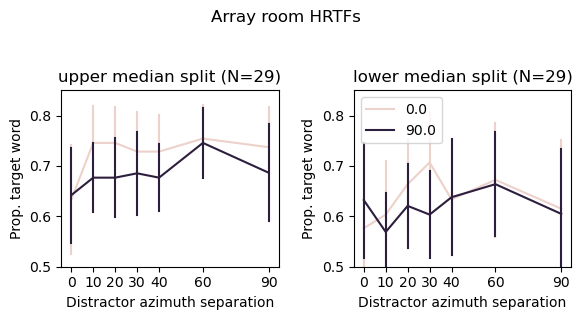

In [17]:
to_analyze_df = analysis_df.copy() 
to_analyze_df['df_index'] = to_analyze_df.index
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()

cutoff = 0.5

participant_names = to_analyze_df.id_subject.unique()
valid_participants = participant_names[(to_analyze_df.groupby('id_subject').adjusted_accuracy.mean() >= cutoff ) ]
print(f"Number of participants with mean adjusted accuracy >= {cutoff} is {len(valid_participants)}")
to_analyze_df = to_analyze_df[to_analyze_df.id_subject.isin(valid_participants)]

## change srm sampling to take last half of trials for each participant
n_half_trials_per_subject = to_analyze_df.groupby(['id_subject']).trial_index.max() // 2 
n_trials_per_subject = n_half_trials_per_subject.to_dict()

# for each participant, only get rows from to_analyize_df if trial_index is greater than their value in n_trials_per_subject
srm_trials = to_analyze_df[to_analyze_df.apply(lambda row: row.trial_index >= n_trials_per_subject[row.id_subject], axis=1)]
srm_trials = srm_trials[( srm_trials.dist_azim_delta.isin([0, 90]))]
# \
# srm_trials = to_analyze_df[to_analyze_df.dist_azim_delta.isin([0, 90])].groupby(['id_subject', "target_azim", 'dist_azim_delta']).apply(lambda x: x.sample(frac=0.5)).reset_index(drop=True)

srm_summary_df = (srm_trials.groupby([ "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

# flatten multiindex 
srm_summary_df.columns = ['_'.join(col).strip() for col in srm_summary_df.columns.values]
# remove trailing underscore
srm_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in srm_summary_df.columns.values]

# analysis trials will be rest of trials not in srm_trials 
analysis_trials = to_analyze_df[~to_analyze_df.df_index.isin(srm_trials.df_index)]

part_summary_df = (analysis_trials.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


## get SRM for each participant using srm_trials 
srm = srm_summary_df.groupby('id_subject').apply(get_srm)
median_srm = srm.quantile(0.5) #srm.median()
upper_split_parts = srm[srm > median_srm].index
lower_split_parts = srm[srm < median_srm].index

upper_split_df = part_summary_df[part_summary_df.id_subject.isin(upper_split_parts)]
lower_split_df = part_summary_df[part_summary_df.id_subject.isin(lower_split_parts)]

# plot split half data
n_pannels = 2
height, width = 3, 3*n_pannels
fig, axs = plt.subplots(1, n_pannels, figsize=(width, height), sharey=False)

plot_dict = {'upper': upper_split_df, 'lower': lower_split_df}
plot_keys = list(plot_dict.keys())  

for ix, cutoff in enumerate(range(n_pannels)):
    split  = plot_keys[ix]
    data = plot_dict[split]
    N = data.id_subject.nunique()
    g = sns.lineplot(data=data,
                    x='dist_azim_delta',
                    y='adjusted_accuracy_mean',
                    hue='target_azim',
                    errorbar=('se', 2),
                    err_style='bars',
                    ax=axs[ix]
                )
    g.set_xlabel("Distractor azimuth separation")
    g.set_ylabel( "Prop. target word")
    g.set(xticks=data.dist_azim_delta.unique())
    g.legend().set_visible(False)
    g.set_title(f"{split} median split (N={N})")
    # axs[ix].set_yticks(np.arange(0.5,0.86,0.05))


    if ix == 1:
        g.legend(title="Target\nazimuth $\degree$")
        g.legend(loc='upper left')
plt.suptitle('Array room HRTFs', y=1.05)
plt.tight_layout()
axs[0].set_ylim(0.5, 0.85)
axs[1].set_ylim(0.5, 0.85)

In [18]:
# get trial data excluding catch trials 
to_summary = analysis_df[analysis_df.condition == 'spatialized']

part_summary_df = (to_summary.groupby(["target_azim", "distractor_azim", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


# add distractor azimuth to dataframe. 


In [ ]:
part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean().describe()

count    66.000000
mean      0.669964
std       0.183827
min       0.050926
25%       0.607639
50%       0.712963
75%       0.787037
max       0.888889
Name: adjusted_accuracy_mean, dtype: float64

In [ ]:
summary_df = (part_summary_df.groupby(["target_azim", "distractor_azim"]).agg({"adjusted_accuracy_mean":['mean', 'sem'], "adjusted_confusions_mean":['mean', 'sem']}).reset_index())
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df.columns = [col[:-1] if col.endswith('_') else col for col in summary_df.columns.values]

summary_df.columns = ['target_azim', 'distractor_azim', 'accuracy', 'adj_acc_sem', 'confusions', 'adj_conf_sem']
# summary_df

### Prelim azimuth plots 

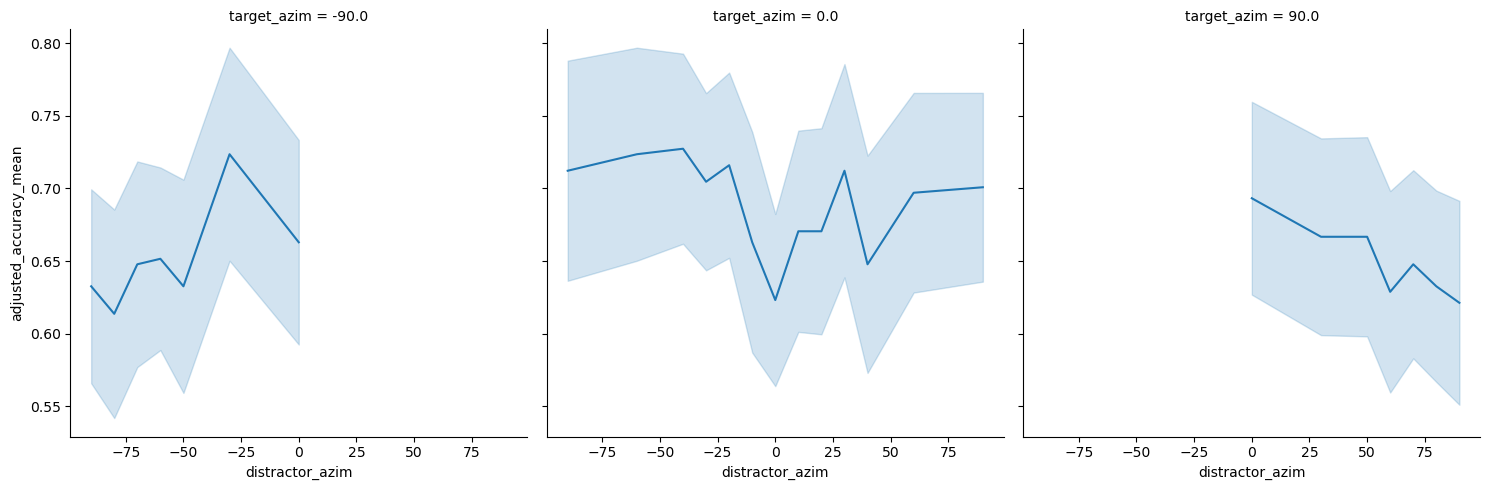

In [21]:
to_plot = part_summary_df.copy()
# to_plot['distractor_azim'] = to_plot['distractor_azim'].abs()
sns.relplot(data=to_plot,
            x='distractor_azim',
            y='adjusted_accuracy_mean',
            col='target_azim',
            errorbar=('se', 2),
            kind='line')

### Plot as function of distractor separation

Text(0.5, 1.05, 'Min. Reverb HRTF (N=66)')

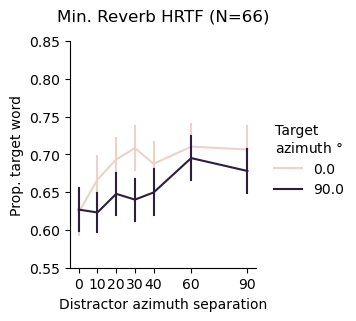

In [22]:
# get trial data excluding catch trials 

to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()
to_analyze_df = to_analyze_df[to_analyze_df.condition != 'srm_trial']
part_summary_df = (to_analyze_df.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

## Compare performance based on mean accuracy allowed per participant


# to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)
g = sns.relplot(data=part_summary_df,
            kind='line',
            x='dist_azim_delta',
            y='adjusted_accuracy_mean',
            hue='target_azim',
            errorbar=('se', 1),
            err_style='bars',
            height=3, aspect=1,
           )
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")

# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=part_summary_df.dist_azim_delta.unique(), yticks=np.arange(0.55, 0.86, 0.05));
# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
N = part_summary_df.id_subject.nunique()

plt.title(f"Min. Reverb HRTF (N={N})", y=1.05)




Text(0.5, 1.05, 'Array room HRTFs')

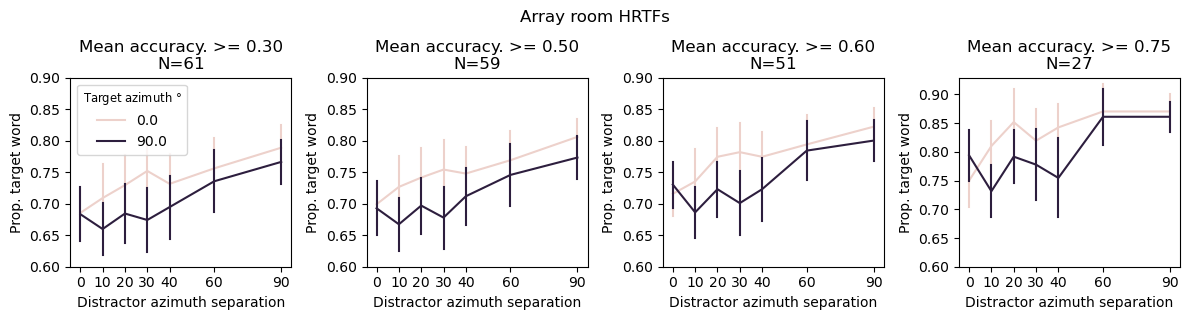

In [23]:
# get trial data excluding catch trials 

to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()

part_summary_df = (to_analyze_df.groupby(["target_azim", "dist_azim_delta", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

## Compare performance based on mean accuracy allowed per participant
mean_cutoffs =  [0.3, .5, .6, .75] #part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean().quantile([0.25, .5, .75,  0.9]).values
n_pannels = len(mean_cutoffs)

height, width = 3, 3*n_pannels
fig, axs = plt.subplots(1, n_pannels, figsize=(width, height), sharey=False)


for ix, cutoff in enumerate(mean_cutoffs):
       participant_names = part_summary_df.id_subject.unique()
       valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= cutoff ]

       to_plot = part_summary_df[part_summary_df.id_subject.isin(valid_participants)].copy()
       g = sns.lineplot(data=to_plot,
                     x='dist_azim_delta',
                     y='adjusted_accuracy_mean',
                     hue='target_azim',
                     errorbar=('se', 2),
                     err_style='bars',
                     ax=axs[ix]
                 )
       g.set_xlabel("Distractor azimuth separation")
       g.set_ylabel( "Prop. target word")
       g.set(xticks=to_plot.dist_azim_delta.unique())
       N = to_plot.id_subject.nunique()
       # plt.title(f"Humans (N={N})")
       g.set_title(f"Mean accuracy. >= {cutoff:.2f}\nN={N}")
       g.legend().set_visible(False)
       if ix == 0:
              g.legend(title="Target azimuth $\degree$", loc='upper left', title_fontsize='small')
              # g.legend()

       axs[ix].set_yticks(np.arange(0.6,0.9,0.05))

# to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)
# g = sns.lineplot(data=to_plot,
#             x='dist_azim_delta',
#             y='adjusted_accuracy_mean',
#             hue='target_azim',
#             errorbar=('se', 2),
#             err_style='bars',
#        #      height=3, aspect=1,
#            )
# g.set_xlabel("Distractor azimuth separation")
# g.set_ylabel( "Prop. target word")
# # plt.ylim(0.4,1)
# # set xticks to be unique dist_azim_delta values 
# g.set(xticks=to_plot.dist_azim_delta.unique())
# # change legend title and set text aiignment to center
# # g._legend.set_title("Target\nazimuth $\degree$")

plt.tight_layout()
plt.suptitle('Array room HRTFs', y=1.05)

Text(0.5, 1.05, 'Array room HRTFs')

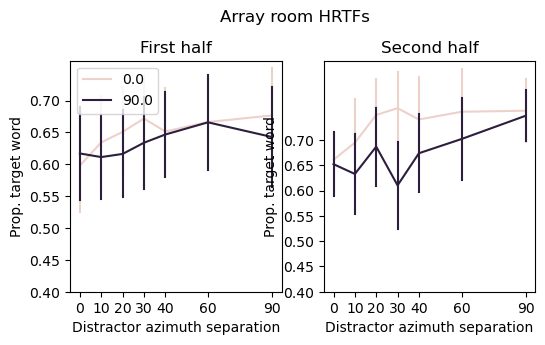

In [24]:
### compare first half to last half of experiment 

cutoff = 0.1
to_analyze_df = analysis_df.copy() 
participant_names = to_analyze_df.id_subject.unique()
valid_participants = participant_names[to_analyze_df.groupby('id_subject').adjusted_accuracy.mean() >= cutoff ]

to_analyze_df = to_analyze_df[to_analyze_df.id_subject.isin(valid_participants)].copy()


to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()

# for each subject, get total n trials. Get only first half of those.
n_trials_per_subject = to_analyze_df.groupby('id_subject').trial_index.max()

# sample first half of trials per subject 
# for subject in n trials per subject, take first half of trials
first_half_trials = []
second_half_trials = []
for subject, n_trials in n_trials_per_subject.items():
       first_half_trials.append(to_analyze_df[to_analyze_df.id_subject.eq(subject) & to_analyze_df.trial_index.le(n_trials//2)])
       second_half_trials.append(to_analyze_df[to_analyze_df.id_subject.eq(subject) & to_analyze_df.trial_index.ge(n_trials//2)])

first_half_df = pd.concat(first_half_trials, axis=0, ignore_index=True)
second_half_df = pd.concat(second_half_trials, axis=0, ignore_index=True)

# get summary stats for each half
first_half_summary = (first_half_df.groupby(["target_azim", "dist_azim_delta", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


first_half_summary.columns = ['_'.join(col).strip() for col in first_half_summary.columns.values]
# remove trailing underscore
first_half_summary.columns = [col[:-1] if col.endswith('_') else col for col in first_half_summary.columns.values]



second_half_summary = (second_half_df.groupby(["target_azim", "dist_azim_delta", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
second_half_summary.columns = ['_'.join(col).strip() for col in second_half_summary.columns.values]
# remove trailing underscore
second_half_summary.columns = [col[:-1] if col.endswith('_') else col for col in second_half_summary.columns.values]




height, width = 3, 6
fig, axs = plt.subplots(1, 2, figsize=(width, height), sharey=False)


for ix in range(2):
       if ix == 0:
              to_plot = first_half_summary
              title="First half"
       elif ix == 1:
              to_plot = second_half_summary
              title="Second half"
       g = sns.lineplot(data=to_plot,
                     x='dist_azim_delta',
                     y='adjusted_accuracy_mean',
                     hue='target_azim',
                     errorbar=('se', 2),
                     err_style='bars',
                     ax=axs[ix]
                 )
       g.set_xlabel("Distractor azimuth separation")
       g.set_ylabel( "Prop. target word")
       g.set(xticks=to_plot.dist_azim_delta.unique(), yticks=np.arange(0.4, 0.71, 0.05))
       g.set_title(title)
       g.legend().set_visible(False)
       if ix == 0:
              g.legend(title="Target\nazimuth $\degree$")
              g.legend(loc='upper left')
plt.suptitle('Array room HRTFs', y=1.05)


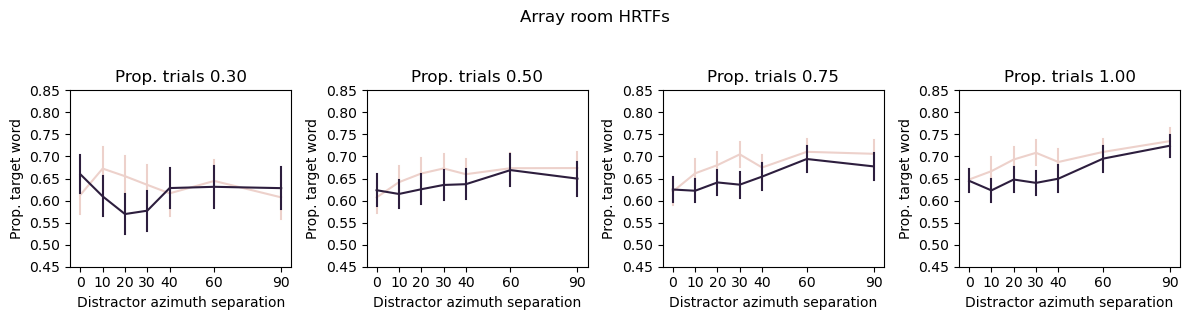

In [25]:
### compare first half to last half of experiment 

# cutoff = 0.6
to_analyze_df = analysis_df.copy() 


to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()

# for each subject, get total n trials. Get only first half of those.
n_trials_per_subject = to_analyze_df.groupby('id_subject').trial_index.max()


cutoffs =  [0.3, .5, .75, 1] #part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean().quantile([0.25, .5, .75,  0.9]).values
n_pannels = len(cutoffs)

height, width = 3, 3*n_pannels
fig, axs = plt.subplots(1, n_pannels, figsize=(width, height), sharey=False)

for ix, cutoff in enumerate(cutoffs):
       split_trials = []
       for subject, n_trials in n_trials_per_subject.items():
              split_trials.append(to_analyze_df[to_analyze_df.id_subject.eq(subject) & to_analyze_df.trial_index.le(int(n_trials * cutoff))])
       split_df = pd.concat(split_trials, axis=0, ignore_index=True)
       # get summary stats for each half
       split_summary = (split_df.groupby(["target_azim", "dist_azim_delta", 'id_subject'])
                            .agg({'correct':['mean', 'count'],
                                   'confusions':['mean'],
                                   'adjusted_accuracy':['mean'],
                                   'adjusted_confusions':['mean']})
                            .reset_index())


       split_summary.columns = ['_'.join(col).strip() for col in split_summary.columns.values]
       # remove trailing underscore
       split_summary.columns = [col[:-1] if col.endswith('_') else col for col in split_summary.columns.values]
       g = sns.lineplot(data=split_summary,
                     x='dist_azim_delta',
                     y='adjusted_accuracy_mean',
                     hue='target_azim',
                     errorbar=('se', 1),
                     err_style='bars',
                     ax=axs[ix]
                 )
       g.set_xlabel("Distractor azimuth separation")
       g.set_ylabel( "Prop. target word")
       g.set(xticks=to_plot.dist_azim_delta.unique())
       g.set_title(title)
       g.legend().set_visible(False)
       g.set_title(f"Prop. trials {cutoff:.2f}")
       axs[ix].set_yticks(np.arange(0.45,0.9,0.05))


       # if ix == 0:
       #        g.legend(title="Target\nazimuth $\degree$")
       #        g.legend(loc='upper left')
plt.suptitle('Array room HRTFs', y=1.05)
plt.tight_layout()

## Look at median split of data 
Get srm delta per participant, than split participants at the median value

/tmp/ipykernel_1987157/3778150061.py:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  co_loc = front_data[part_df.dist_azim_delta == 0].adjusted_accuracy_mean.mean()


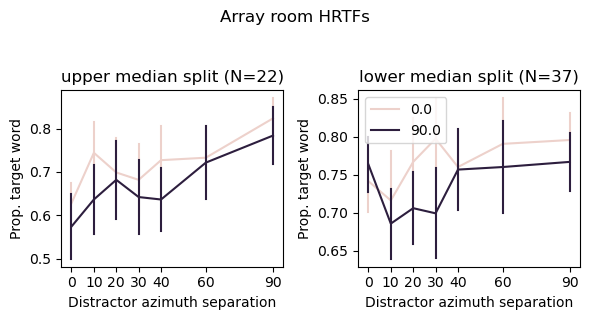

In [26]:
to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()




part_summary_df = (to_analyze_df.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

cutoff = 0.5

participant_names = part_summary_df.id_subject.unique()
valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= cutoff ]

part_summary_df = part_summary_df[part_summary_df.id_subject.isin(valid_participants)]



# split_half_df = part_summary_df[part_summary_df.target_azim == 90].copy()

# for each subject, srm is mean  mean max separation - co located
def get_avg_srm(part_df, target_azims = [0, 90]):
    # front srm 
    srms = []
    for target_azim in target_azims:
        front_data = part_df[part_df.target_azim == target_azim]
        co_loc = front_data[part_df.dist_azim_delta == 0].adjusted_accuracy_mean.mean()
        max_sep = part_df[part_df.dist_azim_delta == 90].adjusted_accuracy_mean.mean()
        srms.append(max_sep - co_loc)
    return np.mean(srms)
    # return max_sep - co_loc

srm = part_summary_df.groupby('id_subject').apply(get_avg_srm)
median_srm =  srm.median()
upper_split_parts = srm[srm > median_srm].index
lower_split_parts = srm[srm <= median_srm].index

upper_split_df = part_summary_df[part_summary_df.id_subject.isin(upper_split_parts)]
lower_split_df = part_summary_df[part_summary_df.id_subject.isin(lower_split_parts)]

# plot split half data
n_pannels = 2
height, width = 3, 3*n_pannels
fig, axs = plt.subplots(1, n_pannels, figsize=(width, height), sharey=False)

plot_dict = {'upper': upper_split_df, 'lower': lower_split_df}
plot_keys = list(plot_dict.keys())  

for ix, cutoff in enumerate(range(n_pannels)):
    split  = plot_keys[ix]
    data = plot_dict[split]
    N = data.id_subject.nunique()
    g = sns.lineplot(data=data,
                    x='dist_azim_delta',
                    y='adjusted_accuracy_mean',
                    hue='target_azim',
                    errorbar=('se', 2),
                    err_style='bars',
                    ax=axs[ix]
                )
    g.set_xlabel("Distractor azimuth separation")
    g.set_ylabel( "Prop. target word")
    g.set(xticks=data.dist_azim_delta.unique())
    g.set_title(title)
    g.legend().set_visible(False)
    g.set_title(f"{split} median split (N={N})")
    # axs[ix].set_yticks(np.arange(0.5,0.86,0.05))


    if ix == 1:
        g.legend(title="Target\nazimuth $\degree$")
        g.legend(loc='upper left')
plt.suptitle('Array room HRTFs', y=1.05)
plt.tight_layout()

### Get model data and plot together

In [ ]:
# output_paths

In [28]:
# # Path to results 
# # output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# # match human pilot conditions
# # model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_azimuth_spotlight_experiment").glob("*/*.pkl"))
# stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

# word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
# ix_to_word = {v:k for k,v in word_class_map.items()}

# remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

# results_dfs = []

# model_name_dict = {
#                    'word_task_v08_control_no_attn': 'Baseline CNN',
#                    "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
#                    "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
#                    "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
#                    "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
#                    "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
#                    "word_task_deep_fc_1024_v08": "Deeper Architecture",
#                    "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
#                    "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt",
#                    "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned": "learned no cue trials"
#                   }


# gend_map = {True:'same', False:'diff'}
# for path in output_paths:
#     if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
#         continue
#     if 'modulated' in path.stem:
#         continue 
#     res_dict = pickle.load(open(path, 'rb'))
#     df = pd.DataFrame.from_dict(res_dict)
#     # break
#     df.rename(columns={"results": "accuracy"}, inplace=True)
#     df['model'] = model_name_dict[path.parent.stem]

#     # if not 'min' in path.stem: 
#     #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
#     #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
#     #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
#     #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
#     # else:
#     # # # merge with stim manifest
#     df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
#     df['target_word'] = df['true_word_int'].map(ix_to_word)
#     df['pred_word'] = df['preds'].map(ix_to_word)
#     df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
#     df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
#     if 'clean' in path.stem:
#         snr = 'clean'
#     else:
#         snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
        
#     df['snr'] = snr 
#     df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
#     df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
#     # # map azim to 0-180
#     df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
#     df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
#     df['target_elev'] = df['target_elev'].astype(int)
#     df['distractor_elev'] = df['distractor_elev'].astype(int)
#     df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
#     df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
#     df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
#     df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
#     if 'white_noise' in path.as_posix():
#         df['distractor_type'] = 'white_noise'
#     elif 'texture' in path.as_posix():
#         df['distractor_type'] = 'texture'
#     else:
#         df['distractor_type'] = 'speech'
#     results_dfs.append(df)

# results = pd.concat(results_dfs)


In [29]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/simulate_2024_human_azimuth_spotlight_experiment_human_stim/").glob("*/*.csv"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

model_name_dict = {
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
                   "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
                   "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
                   "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
                   "word_task_deep_fc_1024_v08": "Deeper Architecture",
                   "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
                   "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt",
                   "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned": "learned no cue trials",
                   "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "learned no cue"
                  }


gend_map = {True:'same', False:'diff'}
for path in output_paths:
    # if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
    #     continue

    # res_dict = pickle.load(open(path, 'rb'))
    try:
        df = pd.read_csv(path)
        df = pd.merge(df,
                            manifests[cols_to_merge],
                                        left_on='stim_name', right_on='stim_name', how='left')
        df['response'] = df['pred_word_int'].replace(ix_to_word)
        # df['confusions'] = (df.response == df.distractor_word).astype('int')
        # df['accuracy'] = (df.response == df.word).astype('int')


        # add adjusted accuracy and confusions 
        pred_words = df.response.values
        target_words = df.word.values
        target_transcripts = df.target_transcripts.values
        distractor_words = df.distractor_word.values
        distractor_transcripts = df.distractor_transcripts.values


        adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                    if not isinstance(target_transcript, float) else np.nan
                                    for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                    ])

        adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
                                    if not (isinstance(distractor_transcript, float)) else np.nan
                                    for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
                                    ])

        df['accuracy'] = adjusted_acc
        df['confusions'] = adjusted_confs

        df['target_azim'] = int(re.search('target_azim_(-?\d+)', path.stem).group(0).strip('target_azim_'))
        df['distractor_azim'] = int(re.search('distractor_azim_(-?\d+)', path.stem).group(0).strip('distractor_azim_'))
        df['target_azim'] = df['target_azim'].apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].apply(remap_azim)
        
        
        # df.rename(columns={"results": "accuracy"}, inplace=True)
        df['model'] = model_name_dict[path.stem.split('_target')[0]]
        results_dfs.append(df)
    except Exception as e:
        print(e)
        print(path)
        continue


results = pd.concat(results_dfs)


In [30]:
# grouped_model_results = results.groupby(['model', 'target_azim', 'distractor_azim','sex_cond', 'snr', ]).agg({'accuracy':['mean', 'sem'],
#                                                                                                                      'confusions':['mean', 'sem']}).reset_index()
# # flatten multiindex
# grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# # remove trailing underscore
# grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]

# grouped_model_results['dist_azim_delta'] = grouped_model_results['distractor_azim'] - grouped_model_results['target_azim']
# grouped_model_results.head()

In [ ]:
## Add distractor azim delta to model results 
results['dist_azim_delta'] = results['distractor_azim'] - results['target_azim']


In [32]:
results.columns

Index(['pred_word_int', 'true_word_int', 'accuracy', 'stim_name', 'word',
       'target_transcripts', 'distractor_transcripts', 'distractor_word',
       'response', 'confusions', 'target_azim', 'distractor_azim', 'model',
       'dist_azim_delta'],
      dtype='object')

In [33]:
### Combine human and model dataframes 
participant_names = part_summary_df.id_subject.unique()
# valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= 0.5 ]

# human_to_combine = part_summary_df[part_summary_df.id_subject.isin(valid_participants)].copy()
human_to_combine = part_summary_df.copy()
human_to_combine.columns = ['target_azim', 'dist_azim_delta', 'id_subject', 'correct_mean', 'correct_count', 'confs_mean', 'accuracy', 'confusions']
N = human_to_combine.id_subject.nunique()
human_to_combine['group'] = f"Humans (N={N})"
results['group'] = results['model']

combined_df = pd.concat([human_to_combine, results], axis=0)
combined_df.head()

,target_azim,dist_azim_delta,id_subject,correct_mean,correct_count,confs_mean,accuracy,confusions,group,pred_word_int,true_word_int,stim_name,word,target_transcripts,distractor_transcripts,distractor_word,response,distractor_azim,model
0,0.0,0.0,5769a352f48c3b00016737f9,0.5000,16.0,0.0625,0.5000,0.0625,Humans (N=59),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,58954e2dc88c680001dd4b7e,0.7500,16.0,0.0000,0.9375,0.0000,Humans (N=59),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,5a8b61fcf1408d000176b02f,0.5625,16.0,0.1875,0.6250,0.1875,Humans (N=59),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.0,0.0,5ace82e135eccf0001a11c96,0.6875,16.0,0.0625,0.7500,0.0625,Humans (N=59),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.0,0.0,5b72e785fb359c0001d8f1c2,0.7500,16.0,0.0625,0.7500,0.0625,Humans (N=59),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


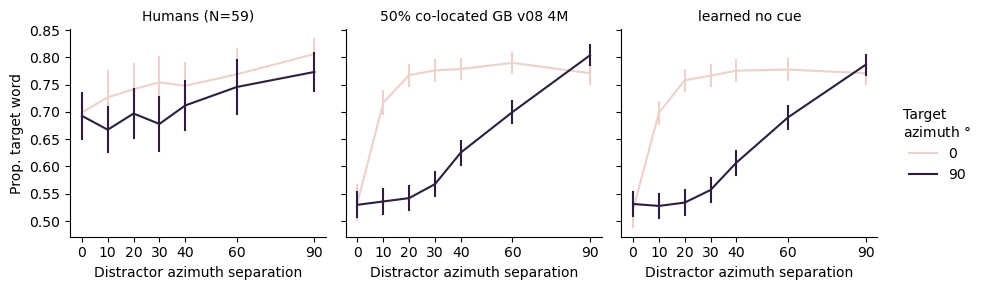

In [34]:
to_plot = combined_df.copy()
to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            col='group',
            height=3, aspect=1,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique(), yticks=np.arange(0.5, 0.86, 0.05));
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")


In [ ]:
combined_df.loc[combined_df.group == 'learned no cue', 'group'] = 'Model'

Text(0.5, 1.05, 'Using array room HRTFs')

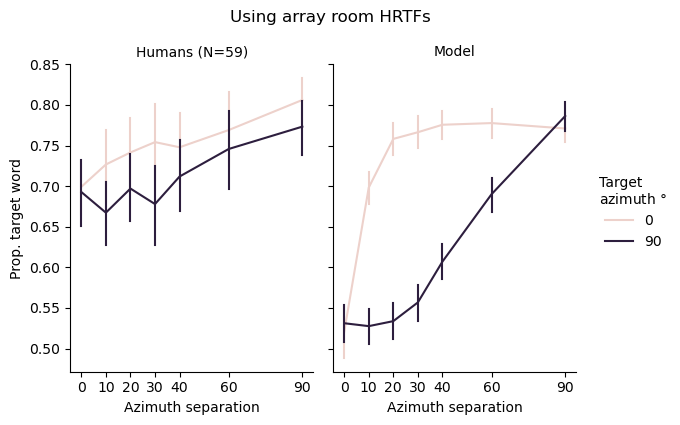

In [36]:
to_plot = combined_df.copy()
to_plot = to_plot[to_plot.group != '50% co-located GB v08 4M']
to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)

to_plot = to_plot[to_plot.dist_azim_delta.le(90)]
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('ci'),
            err_style='bars',
            col='group',
            height=4, aspect=0.75,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique(), yticks=np.arange(0.5, 0.86, 0.05));
# set xtick labels 
# g.set_xticklabels([0, 10, '', 30, '', 60, 90 ])
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
plt.suptitle('Using array room HRTFs', y=1.05)



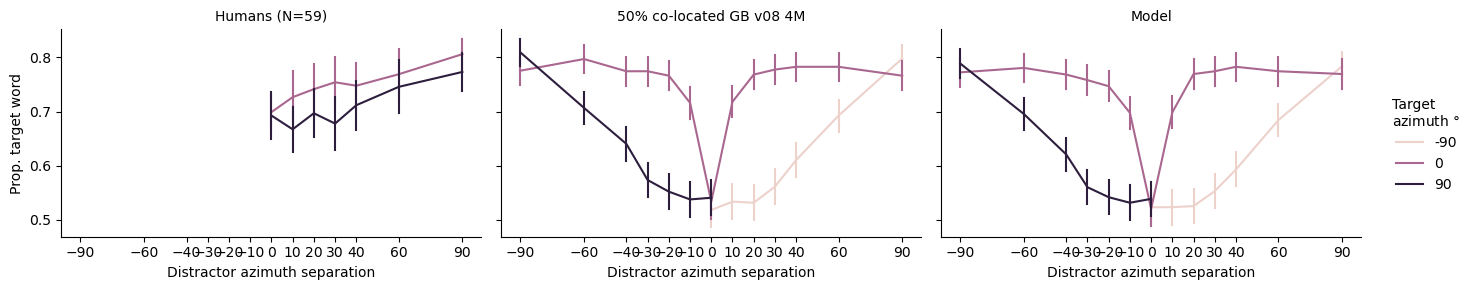

In [37]:
to_plot = combined_df.copy()
# to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].astype(int)
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            col='group',
            height=3, aspect=1.55,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique())
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")


In [38]:
to_plot[to_plot.group == 'Model'].target_azim.unique()

array([  0,  90, -90])

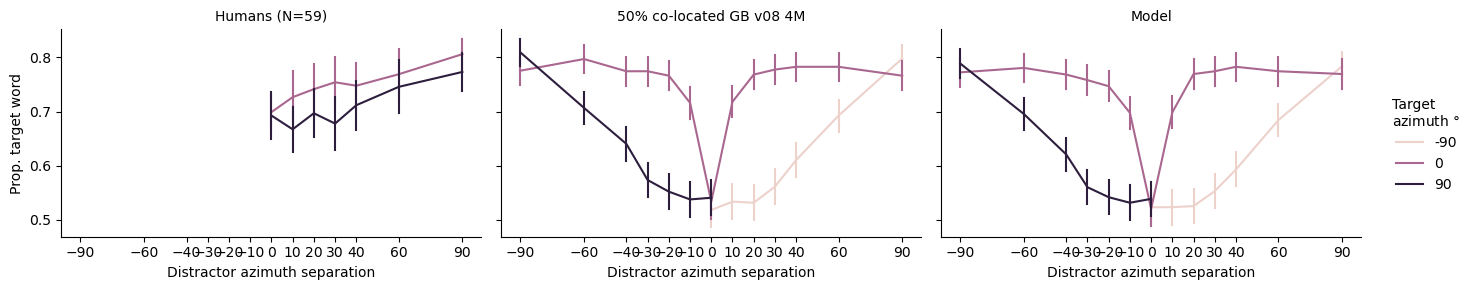

In [39]:
to_plot = combined_df.copy()
# to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].astype(int)
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 2),
            err_style='bars',
            col='group',
            height=3, aspect=1.55,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Distractor azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique())
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")


In [40]:
to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()


part_summary_df = (to_analyze_df.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

cutoff = 0.5

participant_names = part_summary_df.id_subject.unique()
valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= cutoff ]

part_summary_df = part_summary_df[part_summary_df.id_subject.isin(valid_participants)]

human_to_combine = part_summary_df.copy()
human_to_combine.columns = ['target_azim', 'dist_azim_delta', 'id_subject', 'correct_mean', 'correct_count', 'confs_mean', 'accuracy', 'confusions']
N = human_to_combine.id_subject.nunique()
human_to_combine['group'] = f"Humans (N={N})"

humans_to_plot = human_to_combine.copy()

# for each participant, compute the percent improvement over co-located for each target azimuth 
for participant in humans_to_plot.id_subject.unique():
    for target_azim in humans_to_plot.target_azim.unique():
        co_loc_index = (humans_to_plot.id_subject == participant) & (humans_to_plot.dist_azim_delta == 0) & (humans_to_plot.target_azim == target_azim)
        co_loc_perf = humans_to_plot[co_loc_index].accuracy.mean()
        ixs_to_update = (humans_to_plot.id_subject == participant) & (humans_to_plot.target_azim == target_azim)
        humans_to_plot.loc[ixs_to_update, 'percent_improvement'] = humans_to_plot[ixs_to_update].accuracy - co_loc_perf

# get grouped scores 
humans_to_plot = humans_to_plot.groupby(['group', 'target_azim', 'dist_azim_delta']).agg({"accuracy":['mean', 'sem'],
                                                                                     "percent_improvement":['mean', 'sem']}).reset_index()
humans_to_plot.columns = ['_'.join(col).strip() for col in humans_to_plot.columns.values]
# remove trailing underscore
humans_to_plot.columns = [col[:-1] if col.endswith('_') else col for col in humans_to_plot.columns.values]


# model results to merge
model_to_merge = results[results.group == 'learned no cue'].copy()
model_to_merge.target_azim = model_to_merge.target_azim.abs()
model_to_merge.dist_azim_delta = model_to_merge.dist_azim_delta.abs()
model_to_merge_summary = model_to_merge.groupby(["target_azim", "dist_azim_delta", "group"]).agg({'accuracy':['mean', 'sem']}).reset_index()
model_to_merge_summary.columns = ['_'.join(col).strip() for col in model_to_merge_summary.columns.values]
model_to_merge_summary.columns = [col[:-1] if col.endswith('_') else col for col in model_to_merge_summary.columns.values]

model_to_merge_summary.columns = ['target_azim', 'dist_azim_delta', 'group', 'accuracy_mean', "accuracy_sem"]

model_to_merge_summary['id_subject'] = 'Model'
model_to_merge_summary['group'] = "Model"

# add model percent improvement
for target_azim in model_to_merge_summary.target_azim.unique():
    co_loc_index = (model_to_merge_summary.dist_azim_delta == 0) & (model_to_merge_summary.target_azim == target_azim)
    co_loc_perf = model_to_merge_summary[co_loc_index].accuracy_mean.mean()
    ixs_to_update = (model_to_merge_summary.target_azim == target_azim)
    model_to_merge_summary.loc[ixs_to_update, 'percent_improvement_mean'] = model_to_merge_summary[ixs_to_update].accuracy_mean - co_loc_perf


model_to_merge_summary['percent_improvement_sem'] = model_to_merge_summary['accuracy_sem']

summary_to_plot = pd.concat([humans_to_plot, model_to_merge_summary], axis=0)



Text(0.5, 1.05, 'All participants')

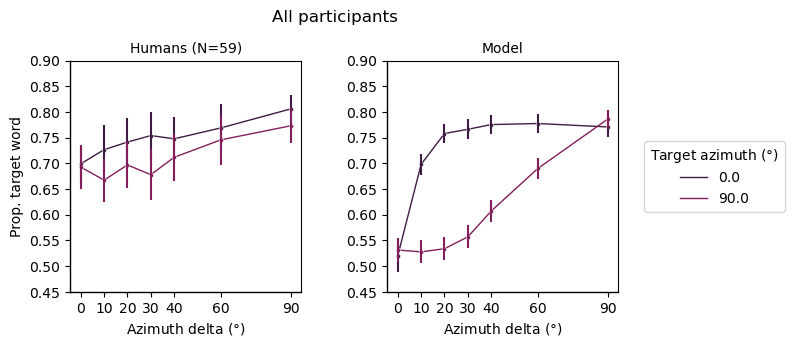

In [41]:

# make lineplot with errorbars from summary_to_plot
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}

aspect = 3
fontsize=10
tick_fontsize = 10
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
models = [f'Humans (N={N})', 'Model']
x_tick_locs = summary_to_plot.dist_azim_delta.unique().astype('int')
x_tick_labels = [str(x) for x in x_tick_locs]

# yticks = np.arange(0,0.31,0.05)
yticks=np.arange(0.45, 0.91, 0.05)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=summary_to_plot[summary_to_plot.group == model],
                x='dist_azim_delta',
                y='accuracy_mean',
                hue='target_azim',
                palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = summary_to_plot[summary_to_plot['group'].eq(model)].copy()
    # select the data for each hue group
    for group, selected in data.groupby('target_azim'):
        # if not group in hue_order:
        #     continue
        # plot the errorbar with the correct color for each group 
        selected['accuracy_sem'] = selected['accuracy_sem'] * 2 
        ax.errorbar(data=selected, x="dist_azim_delta", y="accuracy_mean", yerr="accuracy_sem",
         color=palette[group], marker=None, ls='none', )
        # add errorbar as fill_between 
        # ax.fill_between(selected['dist_azim_delta'], selected['accuracy_mean'] - selected['accuracy_sem'],
        #                  selected['accuracy_mean'] + selected['accuracy_sem'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("Azimuth delta ($\degree$)", fontsize=fontsize)
    if model == 'learned no cue':
        model = 'Model'
    ax.set_title(model, fontsize=fontsize)
    ax.set_yticks(yticks)
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        # if model == 'Feature-gain Model':
        #     line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

axs[0].legend().remove()
axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

handles, labels = axs[1].get_legend_handles_labels()
# remove the errorbars
# handles = [h for h in handles]
# use them in the legend
axs[1].legend(handles[:2], labels[:2], loc='center right',
             bbox_to_anchor=(1.75, 0.5), 
             fontsize=fontsize,title='Target azimuth ($\degree$)')
plt.suptitle('All participants', y=1.05)




## Look at low SRM participants 

In [42]:
to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()


part_summary_df = (to_analyze_df.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

cutoff = 0.5

participant_names = part_summary_df.id_subject.unique()
valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= cutoff ]

part_summary_df = part_summary_df[part_summary_df.id_subject.isin(valid_participants)]



# split_half_df = part_summary_df[part_summary_df.target_azim == 90].copy()

# for each subject, srm is mean  mean max separation - co located
def get_avg_srm(part_df, target_azims = [0, 90]):
    # front srm 
    srms = []
    for target_azim in target_azims:
        front_data = part_df[part_df.target_azim == target_azim]
        co_loc = front_data[part_df.dist_azim_delta == 0].adjusted_accuracy_mean.mean()
        max_sep = part_df[part_df.dist_azim_delta == 90].adjusted_accuracy_mean.mean()
        srms.append(max_sep - co_loc)
    return np.mean(srms)
    # return max_sep - co_loc

srm = part_summary_df.groupby('id_subject').apply(get_avg_srm)
median_srm = srm.quantile(.5) #srm.median()
upper_split_parts = srm[srm > median_srm].index
lower_split_parts = srm[srm <= median_srm].index

lower_split_df = part_summary_df[part_summary_df.id_subject.isin(lower_split_parts)]


### Combine human and model dataframes 
participant_names = lower_split_df.id_subject.unique()
# valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= 0.5 ]

# human_to_combine = part_summary_df[part_summary_df.id_subject.isin(valid_participants)].copy()
human_to_combine = lower_split_df.copy()
human_to_combine.columns = ['target_azim', 'dist_azim_delta', 'id_subject', 'correct_mean', 'correct_count', 'confs_mean', 'accuracy', 'confusions']
N = human_to_combine.id_subject.nunique()
human_to_combine['group'] = f"Humans (N={N})"
results['group'] = results['model']

combined_df = pd.concat([human_to_combine, results], axis=0)



humans_to_plot = human_to_combine.copy()

# for each participant, compute the percent improvement over co-located for each target azimuth 
for participant in humans_to_plot.id_subject.unique():
    for target_azim in humans_to_plot.target_azim.unique():
        co_loc_index = (humans_to_plot.id_subject == participant) & (humans_to_plot.dist_azim_delta == 0) & (humans_to_plot.target_azim == target_azim)
        co_loc_perf = humans_to_plot[co_loc_index].accuracy.mean()
        ixs_to_update = (humans_to_plot.id_subject == participant) & (humans_to_plot.target_azim == target_azim)
        humans_to_plot.loc[ixs_to_update, 'percent_improvement'] = humans_to_plot[ixs_to_update].accuracy - co_loc_perf

# get percent improvement for model 



# # group_baselines = to_plot[to_plot.dist_azim_delta == 0].groupby(['group', 'target_azim']).accuracy.mean().reset_index() 


# get grouped scores 
humans_to_plot = humans_to_plot.groupby(['group', 'target_azim', 'dist_azim_delta']).agg({"accuracy":['mean', 'sem'],
                                                                                     "percent_improvement":['mean', 'sem']}).reset_index()
humans_to_plot.columns = ['_'.join(col).strip() for col in humans_to_plot.columns.values]
# remove trailing underscore
humans_to_plot.columns = [col[:-1] if col.endswith('_') else col for col in humans_to_plot.columns.values]


# model results to merge
model_to_merge = results[results.group == 'learned no cue'].copy()
model_to_merge.target_azim = model_to_merge.target_azim.abs()
model_to_merge.dist_azim_delta = model_to_merge.dist_azim_delta.abs()
model_to_merge_summary = model_to_merge.groupby(["target_azim", "dist_azim_delta", "group"]).agg({'accuracy':['mean', 'sem']}).reset_index()
model_to_merge_summary.columns = ['_'.join(col).strip() for col in model_to_merge_summary.columns.values]
model_to_merge_summary.columns = [col[:-1] if col.endswith('_') else col for col in model_to_merge_summary.columns.values]

model_to_merge_summary.columns = ['target_azim', 'dist_azim_delta', 'group', 'accuracy_mean', "accuracy_sem"]

model_to_merge_summary['id_subject'] = 'Model'
model_to_merge_summary['group'] = "Model"

# add model percent improvement
for target_azim in model_to_merge_summary.target_azim.unique():
    co_loc_index = (model_to_merge_summary.dist_azim_delta == 0) & (model_to_merge_summary.target_azim == target_azim)
    co_loc_perf = model_to_merge_summary[co_loc_index].accuracy_mean.mean()
    ixs_to_update = (model_to_merge_summary.target_azim == target_azim)
    model_to_merge_summary.loc[ixs_to_update, 'percent_improvement_mean'] = model_to_merge_summary[ixs_to_update].accuracy_mean - co_loc_perf


model_to_merge_summary['percent_improvement_sem'] = model_to_merge_summary['accuracy_sem']

summary_to_plot = pd.concat([humans_to_plot, model_to_merge_summary], axis=0)

# summary_to_plot.columns = ['_'.join(col).strip() for col in summary_to_plot.columns.values]
# # remove trailing underscore
# summary_to_plot.columns = [col[:-1] if col.endswith('_') else col for col in summary_to_plot.columns.values]

# # add percent change from co-located
# for group, target_azim in group_baselines[['group', 'target_azim']].values:
#     base_acc = group_baselines[(group_baselines.group == group) & (group_baselines.target_azim == target_azim)].accuracy.values[0]
#     summary_to_plot.loc[(summary_to_plot.group == group) & (summary_to_plot.target_azim == target_azim), 'percent_improvement'] = summary_to_plot[(summary_to_plot.group == group) & (summary_to_plot.target_azim == target_azim)].accuracy_mean - base_acc 


/tmp/ipykernel_1987157/3202049800.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  co_loc = front_data[part_df.dist_azim_delta == 0].adjusted_accuracy_mean.mean()


Text(0.5, 1.05, 'Low SRM participants')

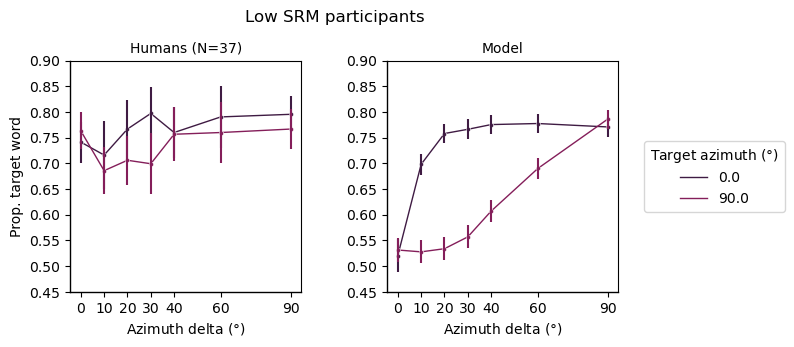

In [43]:
# plot same as above, but now as change in accuracy from co-located 

# make lineplot with errorbars from summary_to_plot
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}

aspect = 3
fontsize=10
tick_fontsize = 10
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
models = [f'Humans (N={N})', 'Model']
x_tick_locs = summary_to_plot.dist_azim_delta.unique().astype('int')
x_tick_labels = [str(x) for x in x_tick_locs]

# yticks = np.arange(0,0.31,0.05)
yticks=np.arange(0.45, 0.91, 0.05)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=summary_to_plot[summary_to_plot.group == model],
                x='dist_azim_delta',
                y='accuracy_mean',
                hue='target_azim',
                palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = summary_to_plot[summary_to_plot['group'].eq(model)].copy()
    # select the data for each hue group
    for group, selected in data.groupby('target_azim'):
        # if not group in hue_order:
        #     continue
        # plot the errorbar with the correct color for each group 
        selected['accuracy_sem'] = selected['accuracy_sem'] * 2 
        ax.errorbar(data=selected, x="dist_azim_delta", y="accuracy_mean", yerr="accuracy_sem",
         color=palette[group], marker=None, ls='none', )
        # add errorbar as fill_between 
        # ax.fill_between(selected['dist_azim_delta'], selected['accuracy_mean'] - selected['accuracy_sem'],
        #                  selected['accuracy_mean'] + selected['accuracy_sem'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("Azimuth delta ($\degree$)", fontsize=fontsize)
    if model == 'learned no cue':
        model = 'Model'
    ax.set_title(model, fontsize=fontsize)
    ax.set_yticks(yticks)
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        # if model == 'Feature-gain Model':
        #     line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

axs[0].legend().remove()
axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

handles, labels = axs[1].get_legend_handles_labels()
# remove the errorbars
# handles = [h for h in handles]
# use them in the legend
axs[1].legend(handles[:2], labels[:2], loc='center right',
             bbox_to_anchor=(1.75, 0.5), 
             fontsize=fontsize,title='Target azimuth ($\degree$)')
plt.suptitle('Low SRM participants', y=1.05)


Text(0.5, 1.05, 'Low SRM participants')

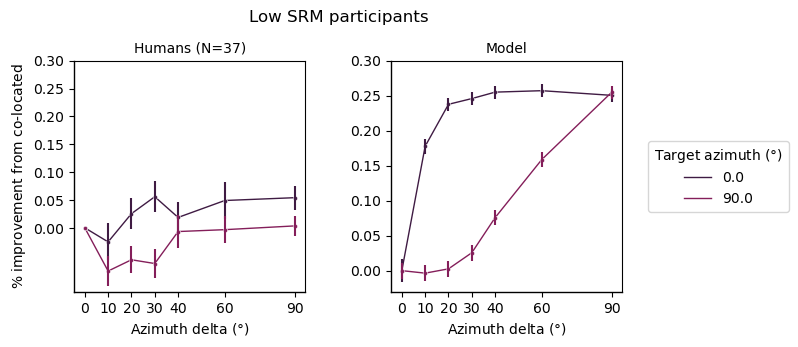

In [44]:
# plot same as above, but now as change in accuracy from co-located 

# make lineplot with errorbars from summary_to_plot
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}

aspect = 3
fontsize=10
tick_fontsize = 10
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
models = [f'Humans (N={N})', 'Model']
x_tick_locs = summary_to_plot.dist_azim_delta.unique().astype('int')
x_tick_labels = [str(x) for x in x_tick_locs]

# yticks = np.arange(0,0.31,0.05)
yticks=np.arange(0.0, 0.31, 0.05)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=summary_to_plot[summary_to_plot.group == model],
                x='dist_azim_delta',
                y='percent_improvement_mean',
                hue='target_azim',
                palette=palette, ax=ax,
                #   errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = summary_to_plot[summary_to_plot['group'].eq(model)].copy()
    # select the data for each hue group
    for group, selected in data.groupby('target_azim'):
        # plot the errorbar with the correct color for each group 
        # selected['percent_improvement_sem'] = selected['percent_improvement_sem'] * 2
        ax.errorbar(data=selected, x="dist_azim_delta", y="percent_improvement_mean", yerr="percent_improvement_sem",
         color=palette[group], marker=None, ls='none', )
        # add errorbar as fill_between 
        # ax.fill_between(selected['dist_azim_delta'], selected['percent_improvement_mean'] - selected['percent_improvement_sem'],
        #                  selected['percent_improvement_mean'] + selected['percent_improvement_sem'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("Azimuth delta ($\degree$)", fontsize=fontsize)
    if model == 'learned no cue':
        model = 'Model'

    ax.set_title(model, fontsize=fontsize)
    ax.set_yticks(yticks)
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        # if model == 'Feature-gain Model':
        #     line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

axs[0].legend().remove()
axs[0].set_ylabel("$\%$ improvement from co-located", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

handles, labels = axs[1].get_legend_handles_labels()
# remove the errorbars
# handles = [h for h in handles]
# use them in the legend
axs[1].legend(handles[:2], labels[:2], loc='center right',
             bbox_to_anchor=(1.75, 0.5), 
             fontsize=fontsize,title='Target azimuth ($\degree$)')
plt.suptitle('Low SRM participants', y=1.05)


## Make same as above but with high SRM participants 

In [45]:
analysis_df.dist_azim_delta.unique()

array([-30.,  90., -90.,  40.,   0., -10.,  60.,  10., -40., -60.,  20.,
       -20.,  30.])

In [46]:
analysis_df.target_azim.unique()

array([ 90., -90.,   0.])

/tmp/ipykernel_1987157/3314381177.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  co_loc = front_data[part_df.dist_azim_delta == 0].adjusted_accuracy_mean.mean()


Text(0.5, 1.05, 'Using array room HRTFs')

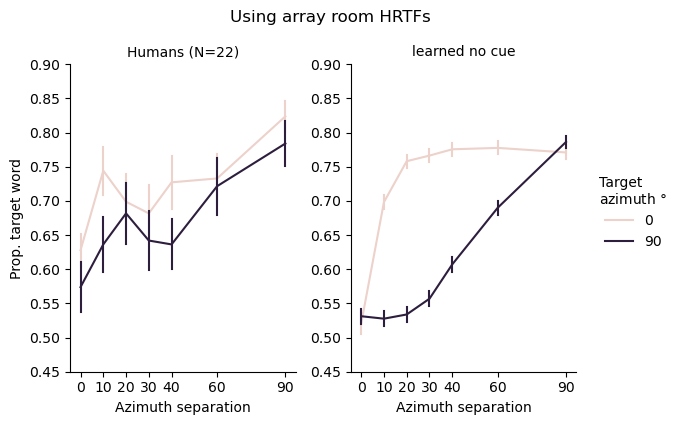

In [47]:
to_analyze_df = analysis_df.copy() 
to_analyze_df["target_azim"] = to_analyze_df.target_azim.abs()
to_analyze_df["dist_azim_delta"] = to_analyze_df.dist_azim_delta.abs()


part_summary_df = (to_analyze_df.groupby(["target_azim", "dist_azim_delta", "id_subject"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

cutoff = 0.5

participant_names = part_summary_df.id_subject.unique()
valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= cutoff ]

part_summary_df = part_summary_df[part_summary_df.id_subject.isin(valid_participants)]



# split_half_df = part_summary_df[part_summary_df.target_azim == 90].copy()

# for each subject, srm is mean  mean max separation - co located
def get_avg_srm(part_df, target_azims = [0, 90]):
    # front srm 
    srms = []
    for target_azim in target_azims:
        front_data = part_df[part_df.target_azim == target_azim]
        co_loc = front_data[part_df.dist_azim_delta == 0].adjusted_accuracy_mean.mean()
        max_sep = part_df[part_df.dist_azim_delta == 90].adjusted_accuracy_mean.mean()
        srms.append(max_sep - co_loc)
    return np.mean(srms)
    # return max_sep - co_loc

srm = part_summary_df.groupby('id_subject').apply(get_avg_srm)
median_srm = srm.quantile(.5) #srm.median()
upper_split_parts = srm[srm > median_srm].index
lower_split_parts = srm[srm <= median_srm].index

upper_split_df = part_summary_df[part_summary_df.id_subject.isin(upper_split_parts)]


### Combine human and model dataframes 
participant_names = upper_split_df.id_subject.unique()
# valid_participants = participant_names[part_summary_df.groupby('id_subject').adjusted_accuracy_mean.mean() >= 0.5 ]

# human_to_combine = part_summary_df[part_summary_df.id_subject.isin(valid_participants)].copy()
human_to_combine = upper_split_df.copy()
human_to_combine.columns = ['target_azim', 'dist_azim_delta', 'id_subject', 'correct_mean', 'correct_count', 'confs_mean', 'accuracy', 'confusions']
N = human_to_combine.id_subject.nunique()
human_to_combine['group'] = f"Humans (N={N})"
results['group'] = results['model']

combined_df = pd.concat([human_to_combine, results], axis=0)
# combined_df.head()
to_plot = combined_df.copy()
to_plot = to_plot[to_plot.group != '50% co-located GB v08 4M']
to_plot['dist_azim_delta'] = to_plot['dist_azim_delta'].abs()
to_plot['target_azim'] = to_plot['target_azim'].abs().astype(int)

# to_plot = to_plot[to_plot.dist_azim_delta.le(90)]
g = sns.relplot(data=to_plot,
            x='dist_azim_delta',
            y='accuracy',
            hue='target_azim',
            errorbar=('se', 1),
            err_style='bars',
            col='group',
            facet_kws={"sharey":False},
            height=4, aspect=0.75,
            kind='line')
g.set_titles("{col_name}")
g.set_axis_labels("Azimuth separation", "Prop. target word")
# plt.ylim(0.4,1)
# set xticks to be unique dist_azim_delta values 
g.set(xticks=to_plot.dist_azim_delta.unique(), yticks=np.arange(0.45, 0.91, 0.05));
# set xtick labels 
# g.set_xticklabels([0, 10, '', 30, '', 60, 90 ])
# change xtick fontsize 

# change legend title and set text aiignment to center
g._legend.set_title("Target\nazimuth $\degree$")
plt.suptitle('Using array room HRTFs', y=1.05)



In [48]:


humans_to_plot = human_to_combine.copy()

# for each participant, compute the percent improvement over co-located for each target azimuth 
for participant in humans_to_plot.id_subject.unique():
    for target_azim in humans_to_plot.target_azim.unique():
        co_loc_index = (humans_to_plot.id_subject == participant) & (humans_to_plot.dist_azim_delta == 0) & (humans_to_plot.target_azim == target_azim)
        co_loc_perf = humans_to_plot[co_loc_index].accuracy.mean()
        ixs_to_update = (humans_to_plot.id_subject == participant) & (humans_to_plot.target_azim == target_azim)
        humans_to_plot.loc[ixs_to_update, 'percent_improvement'] = humans_to_plot[ixs_to_update].accuracy - co_loc_perf

# get percent improvement for model 



# # group_baselines = to_plot[to_plot.dist_azim_delta == 0].groupby(['group', 'target_azim']).accuracy.mean().reset_index() 


# get grouped scores 
humans_to_plot = humans_to_plot.groupby(['group', 'target_azim', 'dist_azim_delta']).agg({"accuracy":['mean', 'sem'],
                                                                                     "percent_improvement":['mean', 'sem']}).reset_index()
humans_to_plot.columns = ['_'.join(col).strip() for col in humans_to_plot.columns.values]
# remove trailing underscore
humans_to_plot.columns = [col[:-1] if col.endswith('_') else col for col in humans_to_plot.columns.values]


# model results to merge
model_to_merge = results[results.group == 'learned no cue'].copy()
model_to_merge.target_azim = model_to_merge.target_azim.abs()
model_to_merge.dist_azim_delta = model_to_merge.dist_azim_delta.abs()
model_to_merge_summary = model_to_merge.groupby(["target_azim", "dist_azim_delta", "group"]).agg({'accuracy':['mean', 'sem']}).reset_index()
model_to_merge_summary.columns = ['_'.join(col).strip() for col in model_to_merge_summary.columns.values]
model_to_merge_summary.columns = [col[:-1] if col.endswith('_') else col for col in model_to_merge_summary.columns.values]

model_to_merge_summary.columns = ['target_azim', 'dist_azim_delta', 'group', 'accuracy_mean', "accuracy_sem"]

model_to_merge_summary['id_subject'] = 'Model'
model_to_merge_summary['group'] = "Model"

# add model percent improvement
for target_azim in model_to_merge_summary.target_azim.unique():
    co_loc_index = (model_to_merge_summary.dist_azim_delta == 0) & (model_to_merge_summary.target_azim == target_azim)
    co_loc_perf = model_to_merge_summary[co_loc_index].accuracy_mean.mean()
    ixs_to_update = (model_to_merge_summary.target_azim == target_azim)
    model_to_merge_summary.loc[ixs_to_update, 'percent_improvement_mean'] = model_to_merge_summary[ixs_to_update].accuracy_mean - co_loc_perf


model_to_merge_summary['percent_improvement_sem'] = model_to_merge_summary['accuracy_sem']

summary_to_plot = pd.concat([humans_to_plot, model_to_merge_summary], axis=0)

# summary_to_plot.columns = ['_'.join(col).strip() for col in summary_to_plot.columns.values]
# # remove trailing underscore
# summary_to_plot.columns = [col[:-1] if col.endswith('_') else col for col in summary_to_plot.columns.values]

# # add percent change from co-located
# for group, target_azim in group_baselines[['group', 'target_azim']].values:
#     base_acc = group_baselines[(group_baselines.group == group) & (group_baselines.target_azim == target_azim)].accuracy.values[0]
#     summary_to_plot.loc[(summary_to_plot.group == group) & (summary_to_plot.target_azim == target_azim), 'percent_improvement'] = summary_to_plot[(summary_to_plot.group == group) & (summary_to_plot.target_azim == target_azim)].accuracy_mean - base_acc 


Text(0.5, 1.05, 'High SRM participants')

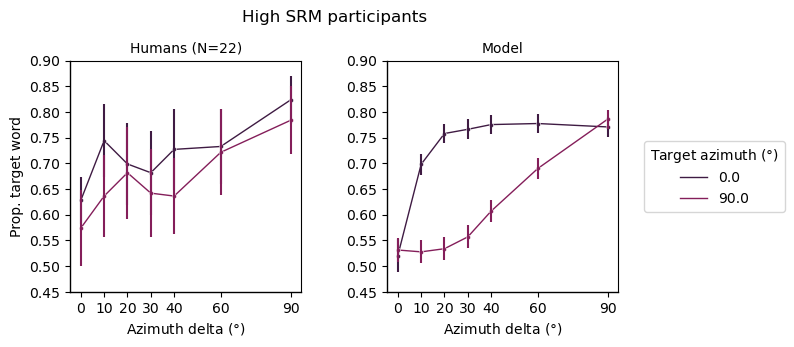

In [49]:
# plot same as above, but now as change in accuracy from co-located 

# make lineplot with errorbars from summary_to_plot
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}

aspect = 3
fontsize=10
tick_fontsize = 10
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
models = [f'Humans (N={N})', 'Model']
x_tick_locs = summary_to_plot.dist_azim_delta.unique().astype('int')
x_tick_labels = [str(x) for x in x_tick_locs]

# yticks = np.arange(0,0.31,0.05)
yticks=np.arange(0.45, 0.91, 0.05)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=summary_to_plot[summary_to_plot.group == model],
                x='dist_azim_delta',
                y='accuracy_mean',
                hue='target_azim',
                palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = summary_to_plot[summary_to_plot['group'].eq(model)].copy()
    # select the data for each hue group
    for group, selected in data.groupby('target_azim'):
        # if not group in hue_order:
        #     continue
        # plot the errorbar with the correct color for each group 
        selected['accuracy_sem'] = selected['accuracy_sem'] * 2 
        ax.errorbar(data=selected, x="dist_azim_delta", y="accuracy_mean", yerr="accuracy_sem",
         color=palette[group], marker=None, ls='none', )
        # add errorbar as fill_between 
        # ax.fill_between(selected['dist_azim_delta'], selected['accuracy_mean'] - selected['accuracy_sem'],
        #                  selected['accuracy_mean'] + selected['accuracy_sem'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("Azimuth delta ($\degree$)", fontsize=fontsize)
    if model == 'learned no cue':
        model = 'Model'
    ax.set_title(model, fontsize=fontsize)
    ax.set_yticks(yticks)
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        # if model == 'Feature-gain Model':
        #     line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

axs[0].legend().remove()
axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

handles, labels = axs[1].get_legend_handles_labels()
# remove the errorbars
# handles = [h for h in handles]
# use them in the legend
axs[1].legend(handles[:2], labels[:2], loc='center right',
             bbox_to_anchor=(1.75, 0.5), 
             fontsize=fontsize,title='Target azimuth ($\degree$)')
plt.suptitle('High SRM participants', y=1.05)


Text(0.5, 1.05, 'High SRM participants')

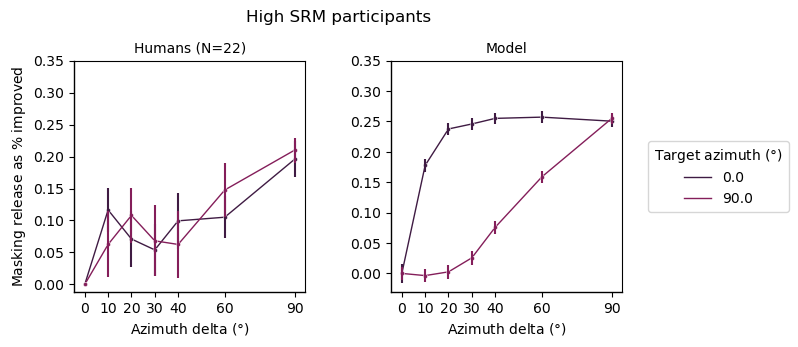

In [50]:
# plot same as above, but now as change in accuracy from co-located 

# make lineplot with errorbars from summary_to_plot
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}

aspect = 3
fontsize=10
tick_fontsize = 10
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
models = [f'Humans (N={N})', 'Model']
x_tick_locs = summary_to_plot.dist_azim_delta.unique().astype('int')
x_tick_labels = [str(x) for x in x_tick_locs]

# yticks = np.arange(0,0.31,0.05)
yticks=np.arange(0.0, 0.36, 0.05)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=summary_to_plot[summary_to_plot.group == model],
                x='dist_azim_delta',
                y='percent_improvement_mean',
                hue='target_azim',
                palette=palette, ax=ax,
                #   errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = summary_to_plot[summary_to_plot['group'].eq(model)].copy()
    # select the data for each hue group
    for group, selected in data.groupby('target_azim'):
        # plot the errorbar with the correct color for each group 
        selected['percent_improvement_sem'] = selected['percent_improvement_sem'] * 1
        ax.errorbar(data=selected, x="dist_azim_delta", y="percent_improvement_mean", yerr="percent_improvement_sem",
         color=palette[group], marker=None, ls='none', )
        # add errorbar as fill_between 
        # ax.fill_between(selected['dist_azim_delta'], selected['percent_improvement_mean'] - selected['percent_improvement_sem'],
        #                  selected['percent_improvement_mean'] + selected['percent_improvement_sem'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("Azimuth delta ($\degree$)", fontsize=fontsize)
    if model == 'learned no cue':
        model = 'Model'

    ax.set_title(model, fontsize=fontsize)
    ax.set_yticks(yticks)
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        # if model == 'Feature-gain Model':
        #     line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

axs[0].legend().remove()
axs[0].set_ylabel("Masking release as $\%$ improved", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

handles, labels = axs[1].get_legend_handles_labels()
# remove the errorbars
# handles = [h for h in handles]
# use them in the legend
axs[1].legend(handles[:2], labels[:2], loc='center right',
             bbox_to_anchor=(1.75, 0.5), 
             fontsize=fontsize,title='Target azimuth ($\degree$)')
plt.suptitle('High SRM participants', y=1.05)
